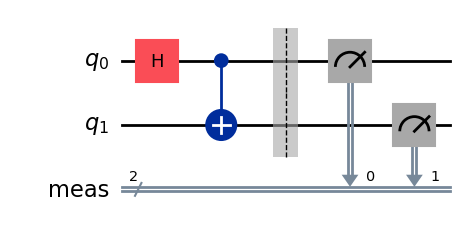

In [23]:
from qiskit import QuantumCircuit # QuantumCircuit class is a builder for quantum programs, defining qubits
from qiskit.visualization import plot_histogram # for observations 
from qiskit_aer import AerSimulator # simulator 
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService

#                   <---------------------------------------THE FIRST BELL STATE-------------------------------------->

bell = QuantumCircuit(2) # instance of quantum circuit class with 2 qubits
#apply hadamard gate
bell.h(0)
#applying cnot gate
bell.cx(0,1)

# now the qubits are entangled, they are in bell state

bell.measure_all() # measure both qubits
bell.draw("mpl")

In [8]:
def run_circuit_and_get_count(circuit,backend,shots=1000):
    """
    This runs a quantum circuit on a specified backend and returns the measurement counts. 
    Args:
        circuit(QuantumCircuit): The quantum circuit to run. 
        backend: The Qiskit backend(real device or simulator)
    returns:
        dict: A dictionary of measurement counts
    """
    pm=generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit=pm.run(circuit)
    
    sampler = Sampler(mode=backend)
    
    job=sampler.run([isa_circuit],shots=shots)
    result=job.result()

    return result[0].data.meas.get_counts() # in return, we get a dictionary 

In [9]:
# Load saved credentials 
service= QiskitRuntimeService()

#Use the least busy backend,or uncomment the loading of a specified backend

backend=service.least_busy(operational=True, simulator=False,min_num_qubits=127)
print(backend.name)
# its using ibm_fez - this quantum computer is running our circuit

qiskit_runtime_service.__init__:WARNING:2026-06-03 11:33:06,177: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-03 11:33:06,686: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-03 11:33:11,188: Using instance: open-instance, plan: open


ibm_marrakesh


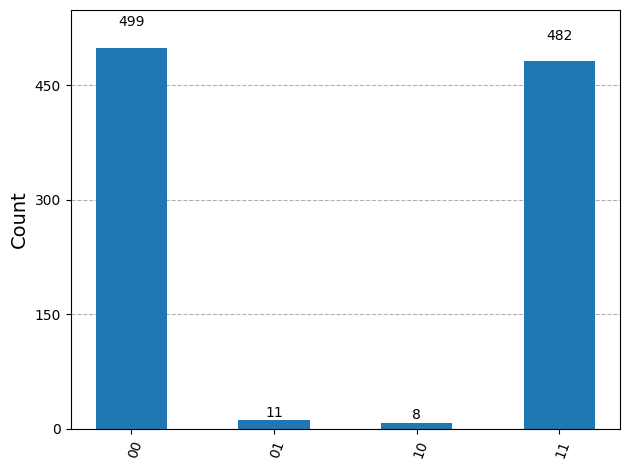

In [10]:
counts=run_circuit_and_get_count(bell, backend,shots=1000)
plot_histogram(counts)
# this still presents some counts of 01 and 10, because real life machines have error margins and noise, but if we code using Aer simulator, it will be 
# a perfet 11 and 00

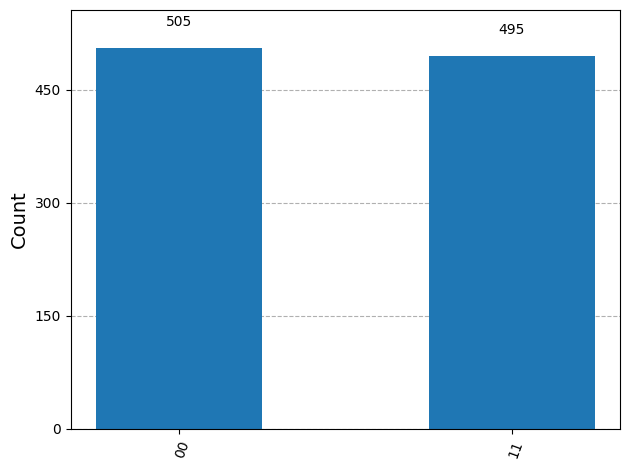

In [11]:
backend=AerSimulator()
counts= run_circuit_and_get_count(bell,backend,shots=1000)

plot_histogram(counts)

# # this shows no 10 and 01, because its a simulator

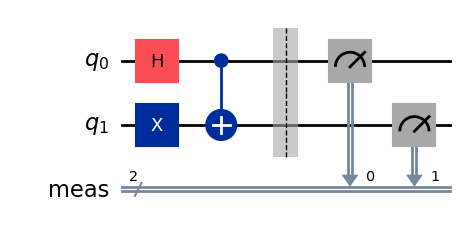

In [12]:
#  <---------------------------------------THE SECOND BELL STATE-------------------------------------->

bell2=QuantumCircuit(2)
bell2.x(1)
bell2.h(0)
bell2.cx(0,1)
bell2.measure_all()
bell2.draw('mpl')

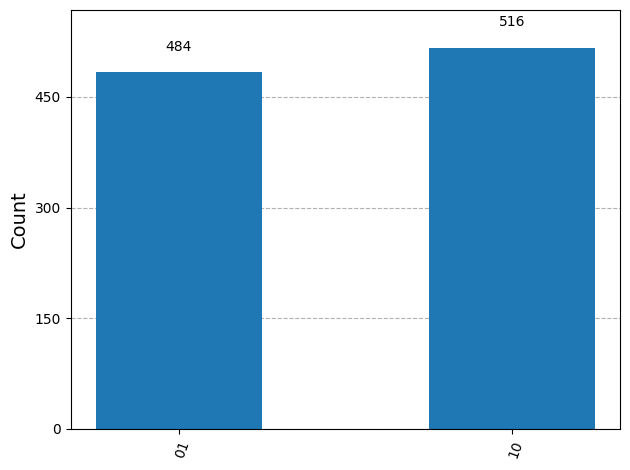

In [13]:
counts=run_circuit_and_get_count(bell2,backend,shots=1000)
plot_histogram(counts)

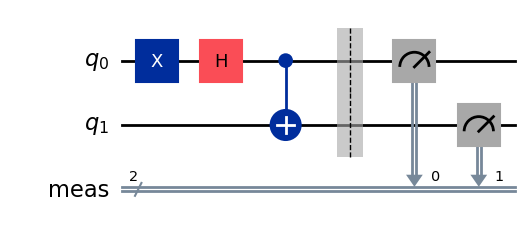

In [16]:
#  <---------------------------------------THE THIRD BELL STATE-------------------------------------->

bell3=QuantumCircuit(2)
bell3.x(0)
bell3.h(0)
bell3.cx(0,1)
bell3.measure_all()
bell3.draw('mpl')

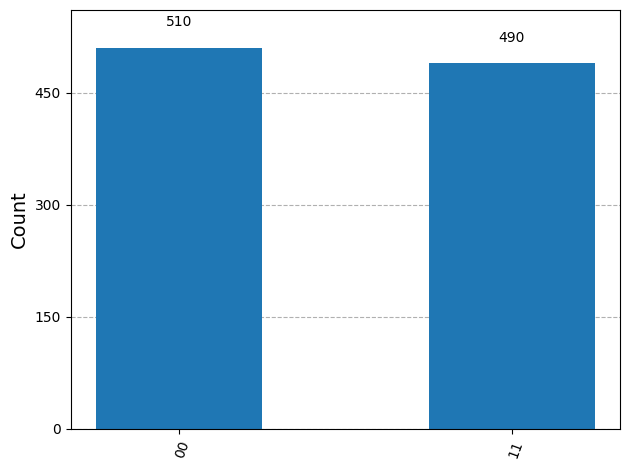

In [17]:
counts=run_circuit_and_get_count(bell3,backend,shots=1000)
plot_histogram(counts)

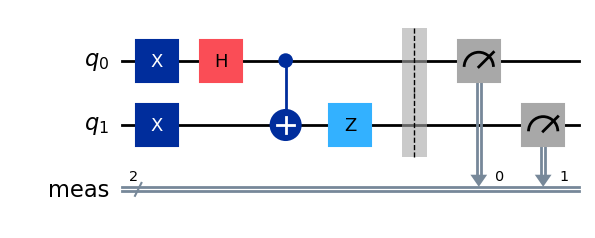

In [20]:
#  <---------------------------------------THE FOURTH BELL STATE-------------------------------------->
bell4=QuantumCircuit(2)
bell4.x(0)
bell4.x(1)
bell4.h(0)
bell4.cx(0,1)
bell4.z(1)
bell4.measure_all()
bell4.draw('mpl')

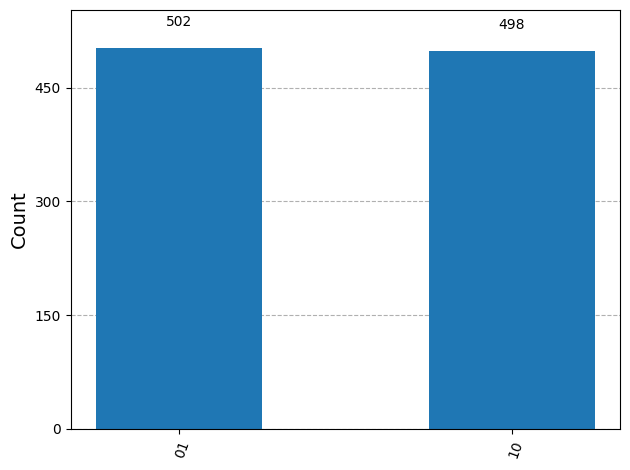

In [27]:
counts=run_circuit_and_get_count(bell2,backend,shots=1000)
plot_histogram(counts)